In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Базовая работа с изображением

In [7]:
image = cv2.imread('sar_2_color.jpg')

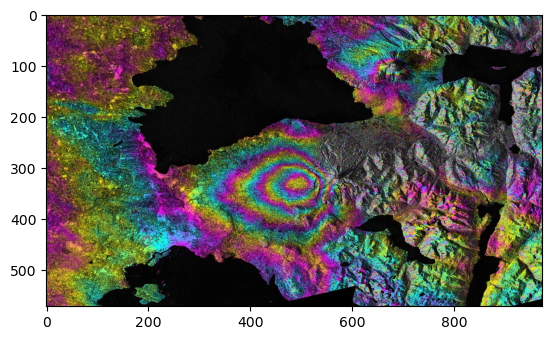

In [8]:
plt.imshow(image)

In [16]:
image.shape # h,w,c

(572, 974, 3)

In [17]:
image[250,250] # b,g,r

array([12, 12, 12], dtype=uint8)

In [18]:
# ROI
img_roi = image[100:200, 500:700]

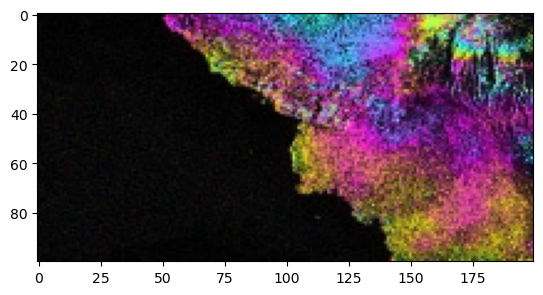

In [19]:
plt.imshow(img_roi)

In [20]:
b,g,r = cv2.split(image)

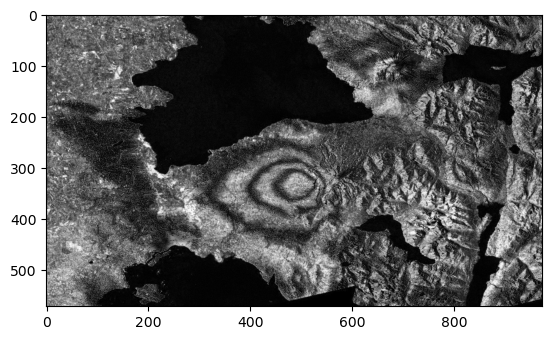

In [21]:
plt.imshow(b, cmap = 'gray')

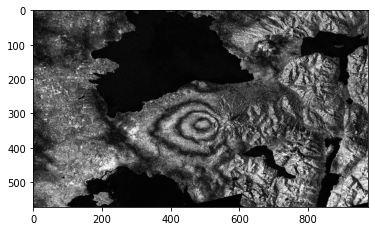

In [24]:
plt.imshow(g, cmap = 'gray')

In [25]:
# alternative approach
b = image[:,:,0]

In [26]:
import copy

image2 = copy.deepcopy(image)

In [27]:
image2[50:100,50:100] = [0,0,0]

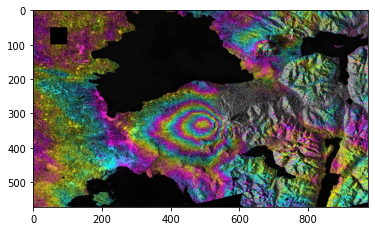

In [28]:
plt.imshow(image2)

In [29]:
# empty image
image_template = np.zeros(image.shape,np.uint8)

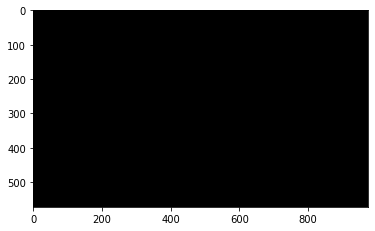

In [30]:
plt.imshow(image_template)

# Конвертация цветовых моделей

In [31]:
image_template[0,0]

array([0, 0, 0], dtype=uint8)

In [54]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

In [33]:
image_gray[0,0]

40

In [34]:
image_gray.shape

(572, 974)

In [35]:
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 

In [36]:
image_hsv.shape

(572, 974, 3)

In [37]:
image_hsv[0,0]

array([117, 143,  75], dtype=uint8)

In [38]:
image[0,0]

array([75, 37, 33], dtype=uint8)

In [39]:
image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)

In [40]:
image_lab[0,0]

array([ 42, 139, 104], dtype=uint8)

# Пороговая фильтрация

In [67]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_BINARY)

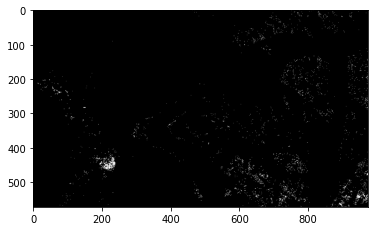

In [68]:
plt.imshow(thresh1, cmap='gray')

In [43]:
thresh1[thresh1==100].sum()

0

# Построение гистограммы

In [44]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)

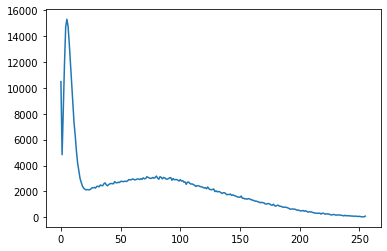

In [45]:
plt.plot(b_hist)

In [46]:
b_hist_cum = b_hist.cumsum()

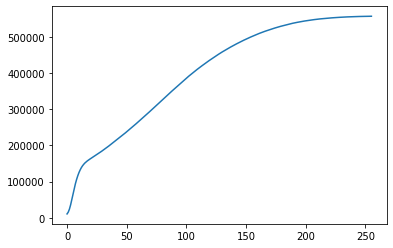

In [47]:
plt.plot(b_hist_cum)

In [49]:
b_hist_norm = b_hist /  (image.shape[0] * image.shape[1])

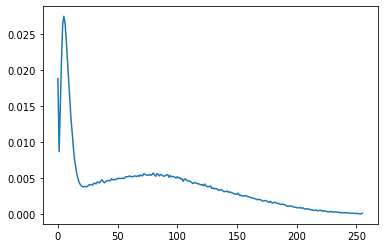

In [50]:
plt.plot(b_hist_norm)

# Сравнение двух изображений

In [55]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_gray, image_gray, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

SSIM: 1.0


In [ ]:
plt.imshow(diff)

In [ ]:
mse = mean_squared_error(image_gray, image_gray)
mse

# Статистические характеристики изображений

In [56]:
mean = image_gray.mean()

In [57]:
std = image_gray.std()

In [58]:
print(mean,std)

67.41225535245043 52.016191875959635


In [60]:
eq_gray = cv2.equalizeHist(image_gray)

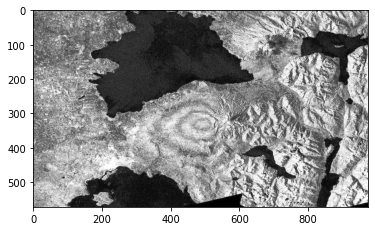

In [63]:
plt.imshow(eq_gray, cmap="gray")


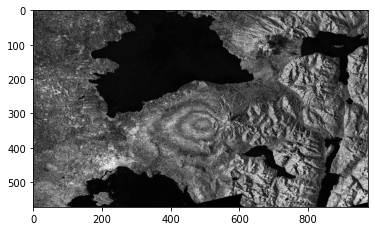

In [64]:
plt.imshow(image_gray, cmap="gray")

In [ ]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. 
# 2. постройте гистограмму
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат


In [25]:
image = cv2.imread('sar_1_gray.jpg')

In [26]:
image_grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

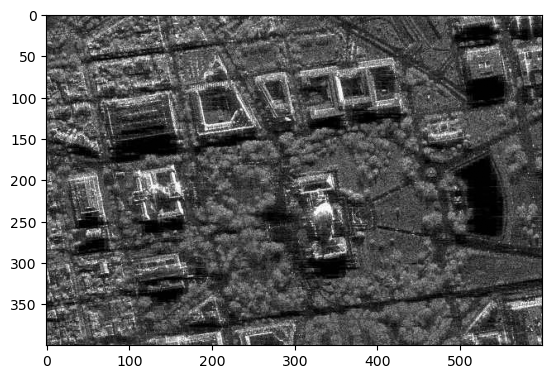

In [27]:
plt.imshow(image_grey, cmap='gray')

In [23]:
histSize = 256
histRange = (0, 256)
accumulate = False

grey_hist = cv2.calcHist([image_grey], [0], None, [histSize], histRange, accumulate=accumulate)

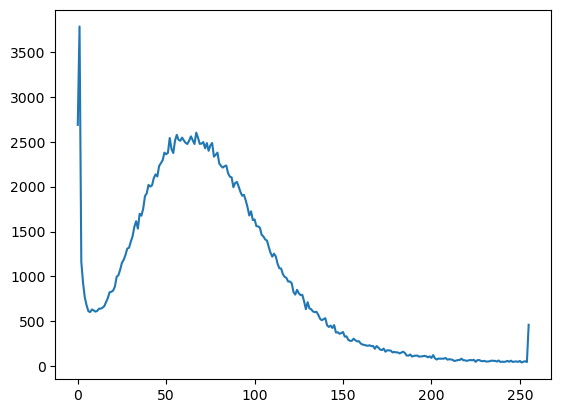

In [24]:
plt.plot(grey_hist)

In [31]:
def gamma_correction(image, gamma):
    return ((image / 255) ** gamma * 255).astype("uint8") 

In [45]:
gamma_light = gamma_correction(image_grey, 0.3)

In [67]:
gamma_dark = gamma_correction(image_grey, 2.7)

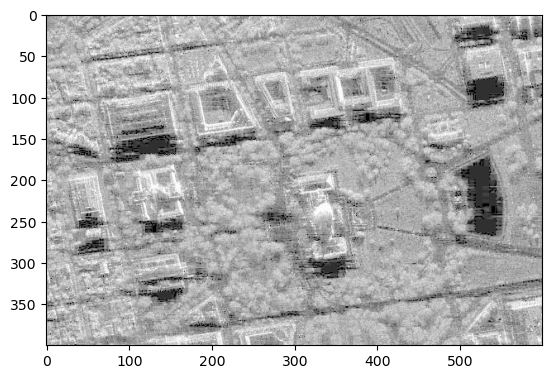

In [46]:
plt.imshow(gamma_light, cmap='gray')

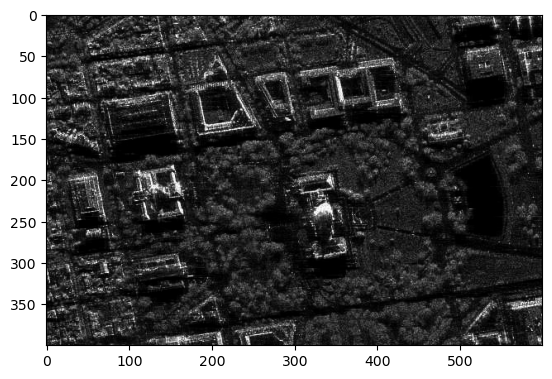

In [44]:
plt.imshow(gamma_dark, cmap='gray')

In [64]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_grey, gamma_dark, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

SSIM: 0.21085324650803924


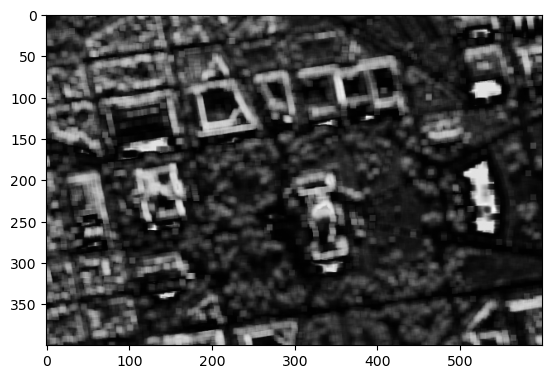

In [65]:
plt.imshow(diff, cmap='gray')

In [66]:
mse = mean_squared_error(image_grey, gamma_dark)
mse

np.float64(4424.039683333333)

In [68]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_grey, gamma_light, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

SSIM: 0.621872695528399


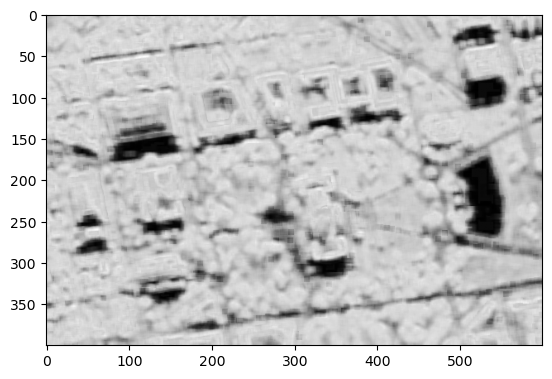

In [69]:
plt.imshow(diff, cmap='gray')

In [70]:
mse = mean_squared_error(image_grey, gamma_light)
mse

np.float64(8929.8311)

In [71]:
mean = image_grey.mean()

In [72]:
std = image_grey.std()

In [73]:
print(mean, std)

74.94157083333333 43.658465466227916


In [74]:
eq_gray = cv2.equalizeHist(image_grey)

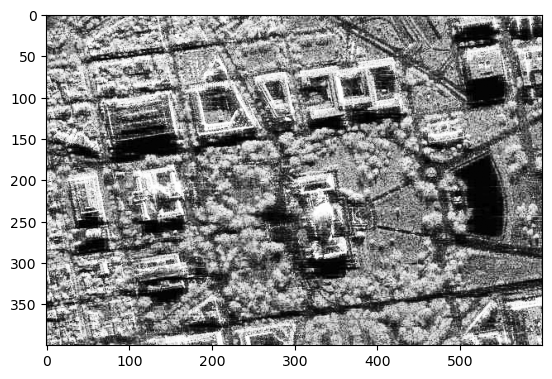

In [75]:
plt.imshow(eq_gray, cmap="gray")

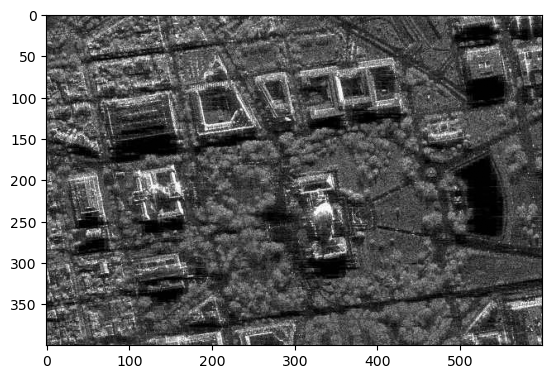

In [76]:
plt.imshow(image_grey, cmap="gray")

In [77]:
mean_eq = eq_gray.mean()
std_eq = eq_gray.std()
print(mean_eq, std_eq)

127.02563333333333 74.26964841889017


In [78]:
image_stat = mean_eq + (image_grey.astype(float) - mean) * std_eq / std
image_stat = np.clip(image_stat, 0, 255).astype("uint8")

In [79]:
print(image_stat.mean(), image_stat.std())

123.1181375 65.3025763098039


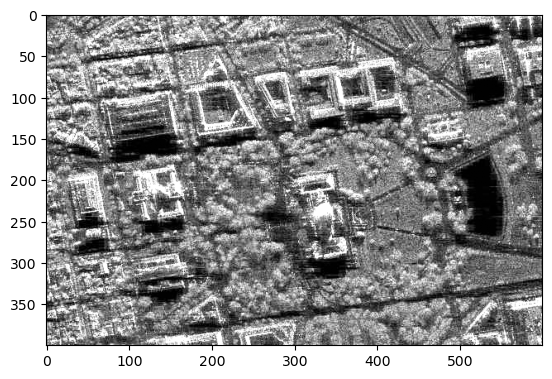

In [80]:
plt.imshow(image_stat, cmap="gray")

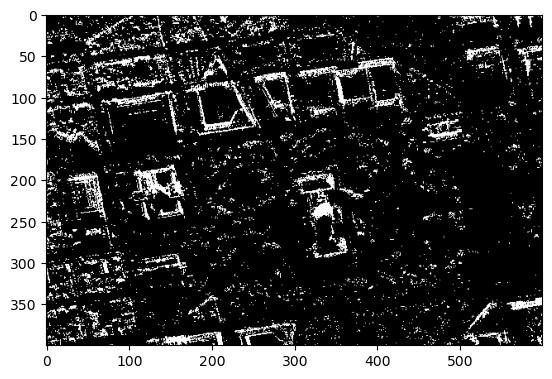

In [89]:
_, thresh_bin = cv2.threshold(image_grey, 128, 255, cv2.THRESH_BINARY)
plt.imshow(thresh_bin, cmap="gray")

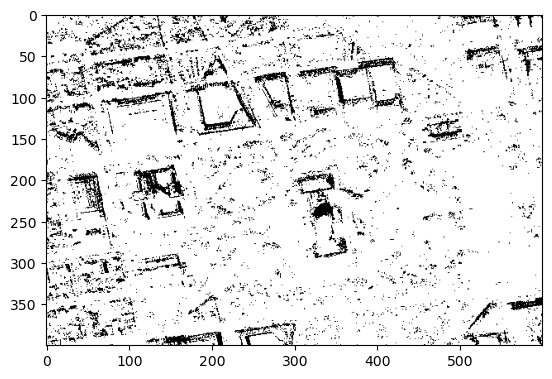

In [90]:
_, thresh_inv = cv2.threshold(image_grey, 128, 255, cv2.THRESH_BINARY_INV)
plt.imshow(thresh_inv, cmap="gray")

In [87]:
thresh_200[thresh_200==100].sum()

np.uint32(0)

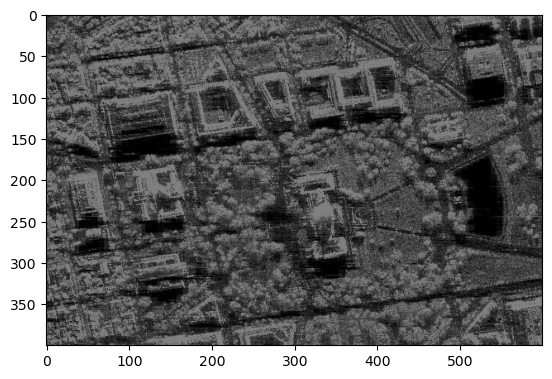

In [91]:
_, thresh_trunc = cv2.threshold(image_grey, 128, 255, cv2.THRESH_TRUNC)
plt.imshow(thresh_trunc, cmap="gray", vmin=0, vmax=255)

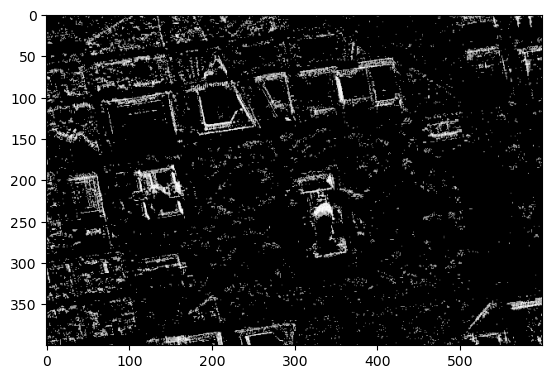

In [92]:
_, thresh_tozero = cv2.threshold(image_grey, 128, 255, cv2.THRESH_TOZERO)
plt.imshow(thresh_tozero, cmap="gray", vmin=0, vmax=255)

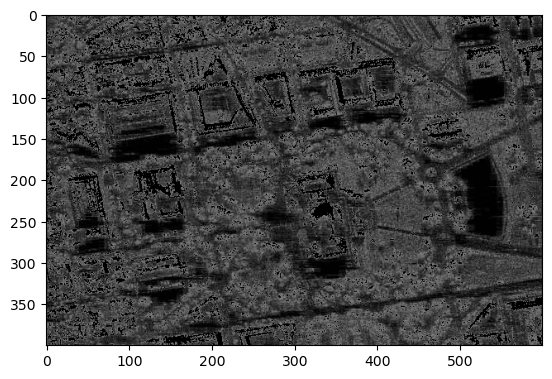

In [93]:
_, thresh_tozero_inv = cv2.threshold(image_grey, 128, 255, cv2.THRESH_TOZERO_INV)
plt.imshow(thresh_tozero_inv, cmap="gray", vmin=0, vmax=255)

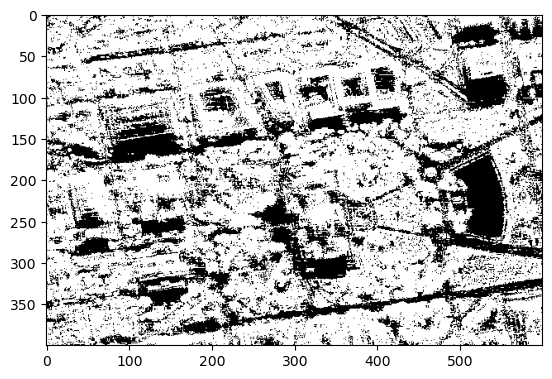

In [94]:
_, thresh_50 = cv2.threshold(image_grey, 50, 255, cv2.THRESH_BINARY)
plt.imshow(thresh_50, cmap="gray")

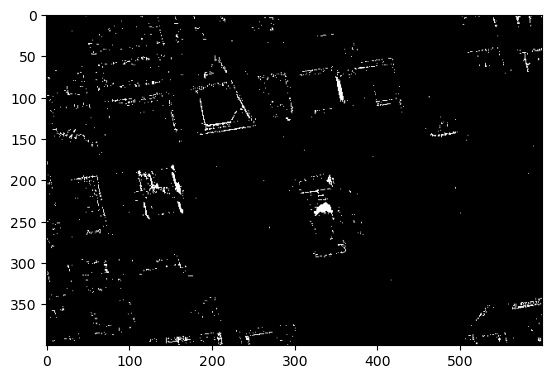

In [95]:
_, thresh_200 = cv2.threshold(image_grey, 200, 255, cv2.THRESH_BINARY)
plt.imshow(thresh_200, cmap="gray")

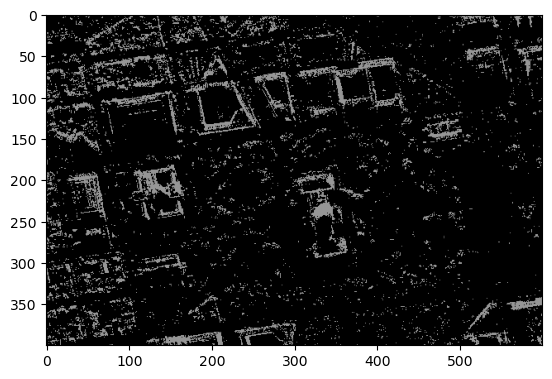

In [96]:
_, thresh_mv = cv2.threshold(image_grey, 128, 150, cv2.THRESH_BINARY)
plt.imshow(thresh_mv, cmap="gray", vmin=0, vmax=255)